<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_1/MULTIVARIATE_NORMAL_boxmuller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np

# Creamos una función que genera total_samples muestras independientes de una distribución normal estándar,
# aplicando el método polar de Box-Muller
def box_muller(total_samples):
    samples = []

    while len(samples) < total_samples: # En cada iteración generamos un par de muestras, por tanto,
                                        # en el caso impar se generaran total_samples + 1 muestras
        # Generamos dos muestras uniformemente distribuidas en (-1,1)
        X1 = 2 * rng.random() - 1
        X2 = 2 * rng.random() - 1

        R = X1 ** 2 + X2 ** 2 # Calculamos el radio

        if 0 < R < 1: # Rechazamos todas las que esten fuera del disco unidad
            # Realizamos la transformacion desarrollada en la parte teorica y añadimos las muestras a nuestro vector samples
            factor = np.sqrt(-2 * np.log(R) / R)
            Y1 = X1 * factor
            Y2 = X2 * factor
            samples.append(Y1)
            samples.append(Y2)

    return np.array(samples)[:total_samples] # En el caso impar, ignoramos el último valor

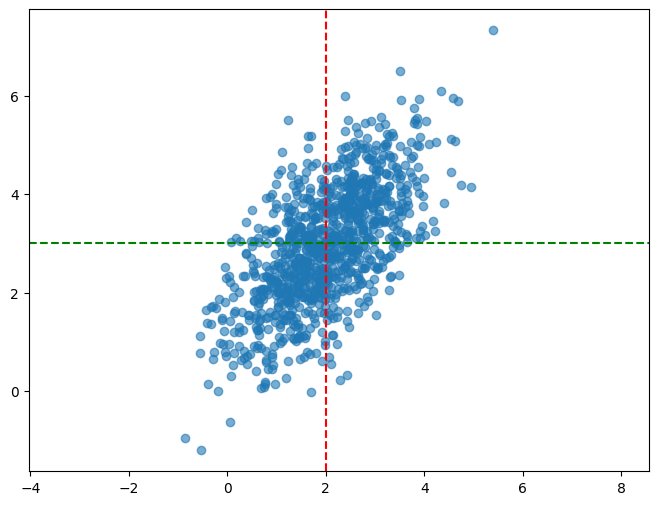

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Establecemos una semilla para la replicabilidad de la imagen
rng = np.random.default_rng(1)

# Definimos los parámetros necesarios para una distribución normal multivariante (de dimensión 2)

# Vector de medias:
mu = np.array([2, 3])

# Matriz de covarianza:
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]]) # Simétrica y definida positiva

# Número de muestras a generar
n_samples = 1000

# Siguiendo los pasos de la sección teórica (Ver Sec. 1.2.2.):
L = np.linalg.cholesky(Sigma) # Descomposición de Choleski

# Reajustamos y producimos el número de muestras a calcular en función de la dimensión
total_standard_samples = mu.shape[0] * n_samples
standard_normal_samples_1d = box_muller(total_standard_samples)

# Reorganizamos para que cada columna sea una muestra con mu.shape[0] componentes
X = standard_normal_samples_1d.reshape(mu.shape[0], n_samples)

Y = mu[:, np.newaxis] + L @ X # Aplicamos la transformación lineal y sumamos la media

Y_samples = Y.T # Trasponemos para que el tratamiento de los datos resulte más intuitivo

# Visualizamos las muestras
plt.figure(figsize=(8, 6))
plt.scatter(Y_samples[:, 0], Y_samples[:, 1], alpha=0.6)

# Visualizamos las medias
plt.axvline(mu[0], linestyle = '--', color='r')
plt.axhline(mu[1], linestyle = '--', color='g')

plt.axis('equal')

# Guardamos la imagen
plt.savefig("NORMAL_MULTIVARIANTE_boxmuller.pdf")

plt.show()

In [9]:
from google.colab import files
files.download("NORMAL_MULTIVARIANTE_boxmuller.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>